In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [2]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

I0000 00:00:1777630301.528557   21663 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5
features_to_vary       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [4]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [5]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [6]:
TARGET = config.target

In [7]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


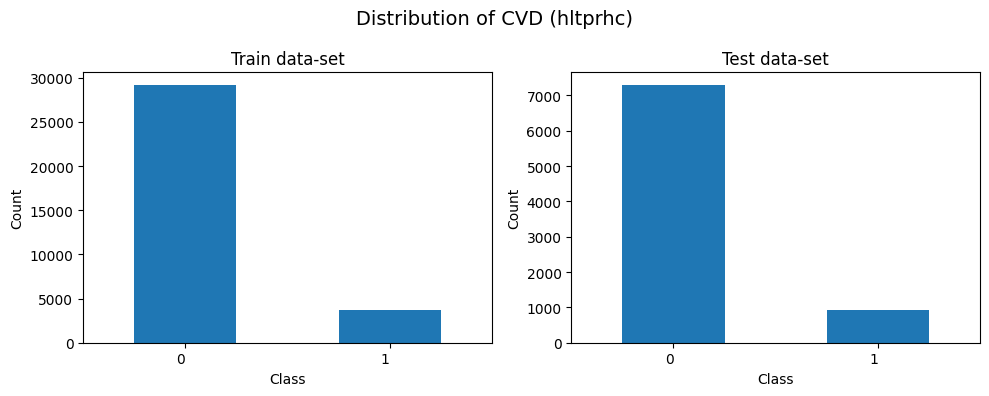

In [8]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

In [10]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

# testing gridsearch on ESS-data, CVD (hltprhc) as target

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipeline = Pipeline(
    [
        ("rf", RandomForestClassifier())
    ]
)

param_dist = {
    "rf__n_estimators":     randint(300, 600),
    "rf__max_depth":        randint(4, 10),
    "rf__min_samples_split":randint(2, 6),
    "rf__min_samples_leaf": randint(1, 4),
    "rf__max_features":     ["sqrt", "log2"],
    "rf__bootstrap":        [True],
    "rf__class_weight":     ["balanced", "balanced_subsample"],
}
rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=200,
    scoring="recall_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train, y_train)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=7, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=371; total time=   4.8s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=7, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=371; total time=   4.9s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=7, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=371; total time=   4.7s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=7, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=371; total time=   4.6s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=7, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=371; total time=   5.3s
[CV] E

In [28]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators
159,7.832857,0.203959,0.176743,0.008645,0.632588,0.636459,0.646024,0.637750,0.619997,0.634563,0.008499,1,True,balanced_subsample,6,sqrt,3,2,450
140,5.403846,0.265773,0.181580,0.014342,0.630030,0.635981,0.644034,0.636851,0.625045,0.634388,0.006449,2,True,balanced,5,sqrt,1,3,582
74,10.346344,0.187031,0.230055,0.009802,0.633739,0.634641,0.647791,0.637124,0.617972,0.634253,0.009560,3,True,balanced_subsample,6,sqrt,3,5,587
183,4.838924,0.213093,0.101419,0.001897,0.629191,0.632566,0.640141,0.636851,0.631840,0.634118,0.003889,4,True,balanced_subsample,4,sqrt,3,4,330
33,3.435908,0.185208,0.113571,0.003040,0.627648,0.633235,0.642354,0.637670,0.629645,0.634110,0.005350,5,True,balanced,4,sqrt,2,2,415
67,3.407862,0.151604,0.134192,0.013787,0.631164,0.635965,0.642955,0.635383,0.624924,0.634078,0.005939,6,True,balanced,5,sqrt,2,4,353
129,5.062437,0.150791,0.170301,0.007083,0.630271,0.631758,0.643400,0.636400,0.628066,0.633979,0.005446,7,True,balanced,4,sqrt,2,3,558
155,6.023853,0.162665,0.205798,0.005996,0.629294,0.637285,0.644258,0.636498,0.621406,0.633748,0.007781,8,True,balanced,5,sqrt,1,2,584
174,3.330912,0.119876,0.109028,0.003122,0.632296,0.633833,0.649008,0.636984,0.616051,0.633635,0.010570,9,True,balanced,6,sqrt,1,4,327
138,9.809634,0.213380,0.201168,0.010361,0.632312,0.632821,0.647138,0.639783,0.615826,0.633576,0.010389,10,True,balanced_subsample,6,sqrt,1,4,588


In [31]:
desired_order = [
    "run_id",
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",
    "rf__n_estimators",
    "rf__min_samples_split",
    "rf__min_samples_leaf",
    "rf__max_features",
    "rf__max_depth",
    "rf__class_weight",
    "rf__bootstrap",
]

top_estimators = top_estimators[desired_order]


### save to csv

In [32]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [ ]:
csv_grid_path = "rf_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [34]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_true, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.93      0.68      0.79      7287
           1       0.20      0.60      0.29       934

    accuracy                           0.67      8221
   macro avg       0.56      0.64      0.54      8221
weighted avg       0.85      0.67      0.73      8221


Roc Score auc score:  0.6417647337122311 



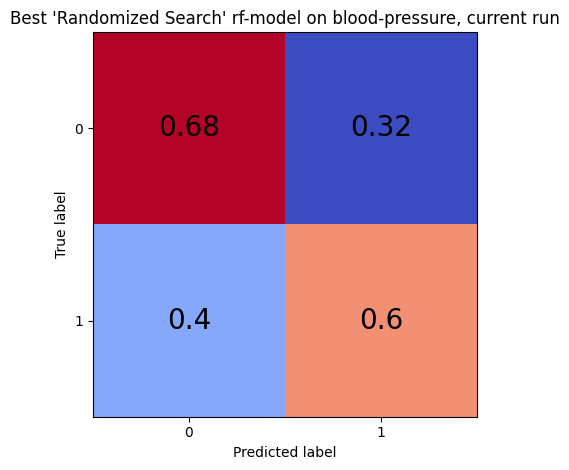

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_rf_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Best 'Randomized Search' rf-model on blood-pressure, current run")
plt.tight_layout()
plt.show()

# Analysis

When training machine‑learning classifiers on imbalanced datasets, it is common to observe a systematic shift in error patterns depending on the choice of class weighting. In the unweighted case, models tend to minimize overall error by favoring the majority class, which typically results in high false‑negative rates for the minority class. This occurs because misclassifying minority‑class samples has little impact on the loss function when the majority class dominates the data distribution.

Applying class weights—such as class_weight="balanced" or class_weight="balanced_subsample"—alters the effective loss landscape by increasing the penalty for misclassifying minority‑class samples. The model is therefore encouraged to prioritize sensitivity (recall) for the minority class. A well‑known consequence of this reweighting is a shift in the decision boundary toward the minority class. As a result, the classifier becomes more likely to label ambiguous samples as belonging to the minority class. This reduces false negatives but simultaneously increases false positives.

This phenomenon is not specific to a particular algorithm. It appears across a wide range of models, including Random Forests, Complement Naive Bayes, and other probabilistic or ensemble methods. The underlying mechanism is the same: class weighting modifies the optimization objective so that the model trades precision for recall in the minority class. When the dataset is strongly imbalanced, this tradeoff becomes especially pronounced, and the model may converge to a region of the parameter space where improvements in recall necessarily come at the cost of increased false‑positive rates.

In the experiments above, Random Forest performance plateaued across a broad hyperparameter search, with mean macro‑recall values varying only marginally. This indicates that the model has reached its performance ceiling under the current data distribution and feature representation. Further hyperparameter tuning is unlikely to yield substantial improvements. Instead, adjustments to the decision threshold, probability calibration, or the use of alternative model families (e.g., gradient‑boosted trees) may be required to achieve a more favorable balance between false positives and false negatives.